# ***Gamma Correction and Tone Mapping***

In [11]:
# Import libraries
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

BASE_DIR = Path.cwd()
DEFAULT_IMAGE_NAME = BASE_DIR / "default_images" / "power_input.jpg"
DEFAULT_TONE_IMAGE_NAME = BASE_DIR / "default_images" / "hdr_input.hdr"


# Import Image
# https://topaz.com.mt/wp-content/uploads/2016/01/Mdina-Sunset-1.jpg
img = cv2.imread(str(DEFAULT_IMAGE_NAME), 1)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # type: ignore

## Power Law

The power law is defined by the equation:
$$ s = C · r^ɣ  $$
Where:
 - $ s $ is the output pixel value
 - $ r $ is the input pixel value (normalised between 0 and 1)
 - $ C $ is a positive scaling constant, typically set to 1 for standard use
 - $ γ $ is the exponent that controls the shape of the transformation

**Visual Effect:**
 - γ > 1 darkens the image (useful for displays with insufficient brightness)
 - γ < 1 brightens the image (useful for displays with excess brightness)
 - γ = 1/2.2 ≈ 0.45 is the standard display gamma correction, converting linear HDR values to display-encoded LDR values for typical monitors

---

In this code example:

```img_f = img.astype(np.float64)```

First converts the image's integer values into float in order to not lose any data in the conversion.

```(img_f / 255.0)```

Normalises the image with values between 0 and 1 in order to effectively make use of the 0 to 1 range in the exponential graph.

```(img_f / 255.0) ** gamma```

The actual power distribution is applied here in order to change the color distribution accordingly.

```c * 255.0 * (img_f / 255.0) ** gamma```

Firstly the result of the above is multiplied by 255 to scale the image's rgb values back to the range 0 to 255. Then the scaling constant c is applied.

```return np.clip(s, 0, 255).astype(np.uint8)```

Here the final result is put in the clip function to ensure the numbers are within the 0 to 255 range. This is just a measure to minimise bugs potentially occurring from rounding errors. Finally, the image's values are converted back to 8-bit integer.


In [12]:
def powerLaw(img, gamma, c=1.0):
	img_f = img.astype(np.float64)
	s = c * 255.0 * (img_f / 255) ** gamma
	return np.clip(s, 0, 255).astype(np.uint8)

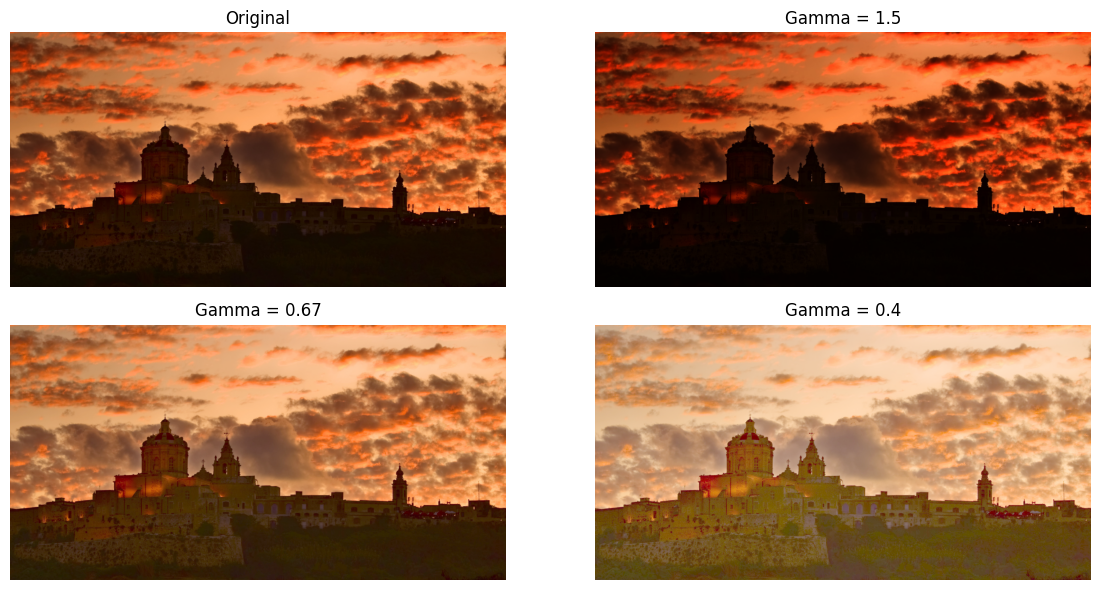

In [13]:
plot, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0, 0].imshow(img)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(powerLaw(img, gamma=1.5))
axes[0, 1].set_title('Gamma = 1.5')
axes[0, 1].axis('off')

axes[1, 0].imshow(powerLaw(img, gamma=0.67))
axes[1, 0].set_title('Gamma = 0.67')
axes[1, 0].axis('off')

axes[1, 1].imshow(powerLaw(img, gamma=0.4))
axes[1, 1].set_title('Gamma = 0.4')
axes[1, 1].axis('off')

plot.tight_layout()

## Tone Mapping Operators

Tone mapping is the process of remapping a high dynamic range image (often with thousands of nits of range) into a low dynamic range output (typically 100 nits for LDR), while preserving as much perceived detail as possible. The below functions do this by remapping the 0 to 1 float values according to the operators, then map them between 0 to 255 and convert them to integers.

In [14]:
# Import HDR Image

# https://polyhaven.com/a/glasshouse_interior
hdr_img = cv2.imread(str(DEFAULT_TONE_IMAGE_NAME), -1)
hdr_img = cv2.cvtColor(hdr_img, cv2.COLOR_BGR2RGB) # type: ignore

The function below behaves the same as the powerLaw function above however:
 - Since the HDR values are already in float they don't need conversion.
 - HDR values are in a floating-point range and may exceed 1.0, so there is no need to do $ /255 $.
 - The clip function is working on 0 to 1 instead of 0 to 255.
 - The $ * 255 $ is done after the clipping in order to ensure the values are within the correct range.

In [15]:
def powerLaw_norm(img, gamma, c=1.0):
    # Power-law (gamma) correction for images in range [0, 1].
    s = c * (img ** gamma)
    return (np.clip(s, 0.0, 1.0) * 255).astype(np.uint8)


### Reinhard Operator

Reinhard tone mapping compresses HDR intensity values into a displayable range.

$$ L_d = \frac{L}{1 + L} $$

Where:

 - $ L $ = HDR luminance value
 - $ L_d $ = tone mapped output value

Visual Effect of Reinhard:
 - Preserves shadow detail
 - Compresses highlights smoothly
 - Produces natural results
 - Can appear slightly flat due to reduced contrast

---

In this code example:

```ldr_img = hdr_img / (hdr_img + 1)```

Here the image is being put in the equation

```reinhard_img = powerLaw_norm(ldr_img, 1.0/2.2)```

This applies gamma correction to compensate for the monitor's gamma encoding. Since modern displays expect gamma-encoded pixel values (not linear), applying γ = 1/2.2 ≈ 0.45 converts our tone-mapped linear values back to the standard display gamma space, ensuring proper brightness and contrast on the viewer's screen.

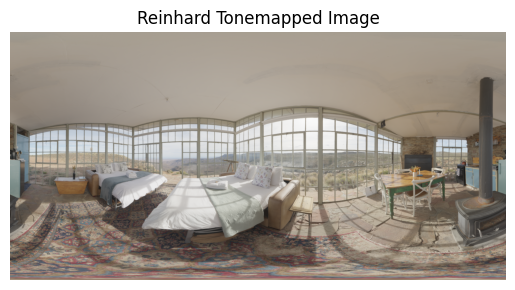

In [16]:
ldr_img = hdr_img / (hdr_img + 1) # type: ignore

# Gamma correction (Standard monitors expect 2.2)
reinhard_img = powerLaw_norm(ldr_img, 1.0/2.2)

plt.imshow(reinhard_img)
plt.title('Reinhard Tonemapped Image')
plt.axis('off')
plt.show()

### Hable Operator

Hable tone mapping is a filmic tone mapping operator designed to mimic the response of camera film.

$$ f(x) = \frac{x(Ax + CB) + DE}{x(Ax + B) + DF} - \frac{E}{F} $$

Where:

 - (x) = HDR input value
 - Constants shape the filmic curve

The curve contains:

 - A toe region for softer shadows
 - A near-linear mid-tone region
 - A shoulder region for smooth highlight compression

Unlike Reinhard, Hable focuses more on cinematic contrast and smoother highlight roll-off. Bright areas compress gradually rather than clipping abruptly, helping preserve detail and producing a more visually pleasing image.
The constants we are using here are typical for a filmic look.

```
A = 0.15 # Shoulder Strength
B = 0.50 # Linear Strength
C = 0.10 # Linear Angle
D = 0.20 # Toe Strength
E = 0.02 # Toe Enumerator
F = 0.30 # Toe Denominator
```

Visual Effect of Hable:

 - Produces cinematic contrast
 - Creates softer highlights
 - Preserves shadow detail
 - Gives a film-like appearance
 - Usually looks less flat than Reinhard

---

In this code example:

```hable_operator(x)```

Is the function that contains the constants and transforms the input from the 0 to 1 range according to the curve. 

```ldr_result = hable_operator(hdr_img)```

Here we are applying the operator onto all the values of the image.

```hable_img = powerLaw_norm(ldr_result, 1.0/2.2)```

This applies gamma correction to compensate for the monitor's gamma encoding. Since modern displays expect gamma-encoded pixel values (not linear), applying γ = 1/2.2 ≈ 0.45 converts our tone-mapped linear values back to the standard display gamma space, ensuring proper brightness and contrast on the viewer's screen.

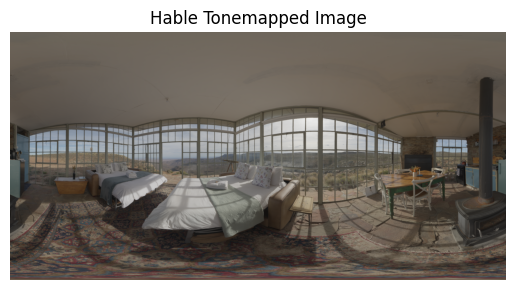

In [17]:
def hable_operator(x):
    # These constants define the shape of the filmic curve
    A = 0.15 # Shoulder Strength
    B = 0.50 # Linear Strength
    C = 0.10 # Linear Angle
    D = 0.20 # Toe Strength
    E = 0.02 # Toe Enumerator
    F = 0.30 # Toe Denominator
    # Equation: ((x*(A*x+C*B)+D*E)/(x*(A*x+B)+D*F))-E/F
    return ((x * (A * x + C * B) + D * E) / (x * (A * x + B) + D * F)) - E / F

ldr_result = hable_operator(hdr_img)

# Gamma correction for your monitor
hable_img = powerLaw_norm(ldr_result, 1.0/2.2)

plt.imshow(hable_img)
plt.title('Hable Tonemapped Image')
plt.axis('off')
plt.show()

### Comparison

While both operators successfully compress the HDR dynamic range into a displayable range, they differ in their approach and visual character. 

Reinhard applies a simple mathematical formula that treats all luminance values uniformly. Since highlights are compressed with the same curve as mid-tones, the result can appear somewhat desaturated or flat at the top end. Hable, on the other hand, uses a piecewise-shaped curve with distinct sections, which allows highlights to roll off more gradually and shadows to retain more local contrast. This gives Hable a richer, more cinematic quality at the cost of being a less intuitive operator to tune.

Another practical difference is white-point handling: the basic Reinhard implementation used here has no explicit white-point parameter, meaning very bright HDR values asymptotically approach 1 but never clip. Hable's curve naturally saturates more aggressively, which can make very bright highlights appear bolder and better separated from mid-tones.

In terms of dynamic range ratio, both outputs will be significantly lower than the HDR source, but Hable often retains a slightly wider perceptual range due to its stronger toe contrast.

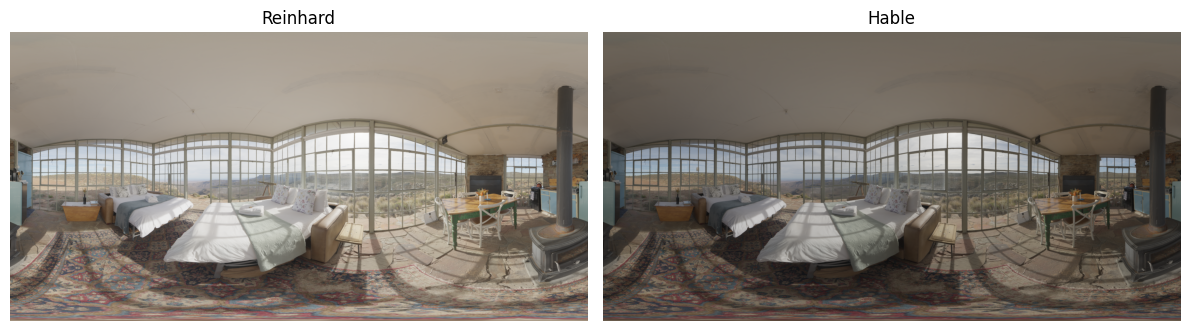

In [18]:
plot, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(reinhard_img)
axes[0].set_title('Reinhard')
axes[0].axis('off')

axes[1].imshow(hable_img)
axes[1].set_title('Hable')
axes[1].axis('off')

plot.tight_layout()

In [19]:
hdr_dr = hdr_img.max() / (hdr_img[hdr_img > 0].min()) # type: ignore
reinhard_dr = reinhard_img.max() / (reinhard_img[reinhard_img > 0].min())
hable_dr = hable_img.max() / (hable_img[hable_img > 0].min())

print("HDR Dynamic Range:", hdr_dr)
print("Reinhard Dynamic Range:", reinhard_dr)
print("Hable Dynamic Range:", hable_dr)

HDR Dynamic Range: 13607.051
Reinhard Dynamic Range: 13.263157894736842
Hable Dynamic Range: 21.818181818181817
